# Título 1
## Títilo 2

# MAPAS BIVARIADOS
## IDG_2026 S-1

Un mapa bivariado permite representar dos variables en el espacio mediante una paleta de colores combinada.

Se utiliza las comillas para `destacar` y ** **negrita**

## LIBRERÍAS

In [37]:
from sqlalchemy import create_engine
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

## 1. Conexión a Base de Datos
Usamos `SQLalchemy` para crear un motor de conexión a PostgresSQL

In [5]:
DB_HOST     = 'localhost'
DB_PORT     = 5432
DB_NAME     = 'censo_v_2017'
DB_USER     = 'postgres'
DB_PASSWORD = 'postgres'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

## 2. Carga de Datos

In [10]:
query_ej = '''
cmxn
egtr
'''

In [11]:
query_ejemplo = '''
SELECT * 
FROM  comunas;
'''

In [12]:
query_ejemplo

'\nSELECT * \nFROM  comunas;\n'

In [13]:
df = pd.read_sql(query_ejemplo, engine)

In [14]:
df

,comuna_ref_id,provincia_ref_id,idcomuna,redcoden,nom_comuna,codigo_comuna
0,41,12,01,05101,VALPARAÍSO,05101
1,42,12,02,05102,CASABLANCA,05102
2,43,12,03,05103,CONCÓN,05103
3,44,12,04,05104,JUAN FERNÁNDEZ,05104
4,45,12,05,05105,PUCHUNCAVÍ,05105
5,46,12,07,05107,QUINTERO,05107
6,47,12,09,05109,VIÑA DEL MAR,05109
7,48,13,01,05201,ISLA DE PASCUA,05201
8,49,14,01,05301,LOS ANDES,05301
9,50,14,02,05302,CALLE LARGA,05302


In [27]:
# Generamos consulta con indicadores a nivel censal
sql_indicadores = '''
WITH agg AS
(SELECT c.nom_comuna, z.geocodigo::double precision AS geocodigo, COUNT(*) FILTER(WHERE p.p15 >= 12 and p.p15 <=14) AS profesionales,
ROUND((COUNT(*) FILTER(WHERE p.p15 >= 12 and p.p15 <=14)*100.0/COUNT(*)), 2) AS "ptje_esc_mayor_16",
ROUND((COUNT(*) FILTER(WHERE p.p12pais <998)*100.0/COUNT(*)), 2) AS "ptje_migrantes"
FROM public.personas AS p
JOIN public.hogares AS h
ON p.hogar_ref_id = h.hogar_ref_id
JOIN public.viviendas AS v
ON h.vivienda_ref_id = v.vivienda_ref_id
JOIN public.zonas AS z
ON v.zonaloc_ref_id = z.zonaloc_ref_id
JOIN public.comunas AS c
ON z.codigo_comuna = c.codigo_comuna
JOIN public.provincias AS pr 
ON pr.provincia_ref_id = c.provincia_ref_id
WHERE pr.nom_provincia = 'SAN ANTONIO'
GROUP BY z.geocodigo, c.nom_comuna
ORDER BY nom_comuna, "ptje_migrantes"
)



SELECT a.*, shp.geom
FROM agg AS a
JOIN dpa.zonas_censales_v AS shp ON shp.geocodigo = a.geocodigo;
'''

In [28]:
gdf = gpd.read_postgis(sql_indicadores, engine, geom_col='geom')

In [29]:
gdf

,nom_comuna,geocodigo,profesionales,ptje_esc_mayor_16,ptje_migrantes,geom
0,ALGARROBO,5.602012e+09,2,4.55,0.00,"MULTIPOLYGON (((-71.63963 -33.35499, -71.63916..."
1,ALGARROBO,5.602011e+09,245,7.19,0.41,"MULTIPOLYGON (((-71.66342 -33.36749, -71.6634 ..."
2,ALGARROBO,5.602021e+09,46,7.18,0.47,"MULTIPOLYGON (((-71.65139 -33.30365, -71.65135..."
3,ALGARROBO,5.602012e+09,28,17.18,0.61,"MULTIPOLYGON (((-71.63115 -33.36498, -71.63038..."
4,ALGARROBO,5.602012e+09,39,30.00,0.77,"MULTIPOLYGON (((-71.62725 -33.36466, -71.62668..."
...,...,...,...,...,...,...
157,SANTO DOMINGO,5.606013e+09,3,9.68,3.23,"MULTIPOLYGON (((-71.54029 -33.75185, -71.54042..."
158,SANTO DOMINGO,5.606011e+09,258,39.94,3.56,"MULTIPOLYGON (((-71.62601 -33.6418, -71.626 -3..."
159,SANTO DOMINGO,5.606012e+09,82,21.08,8.48,"MULTIPOLYGON (((-71.60255 -33.65312, -71.6022 ..."
160,SANTO DOMINGO,5.606012e+09,41,31.30,9.92,"MULTIPOLYGON (((-71.63521 -33.69269, -71.63486..."


<Axes: >

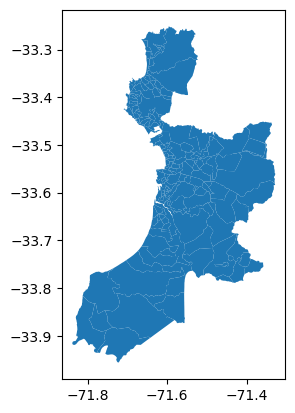

In [30]:
gdf.plot()

<Axes: >

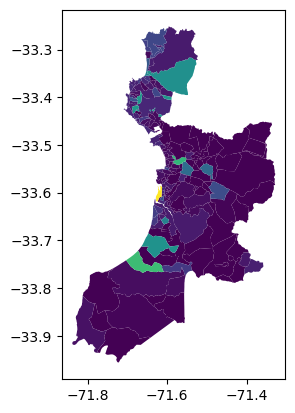

In [31]:
gdf.plot(column='ptje_migrantes')

<Axes: >

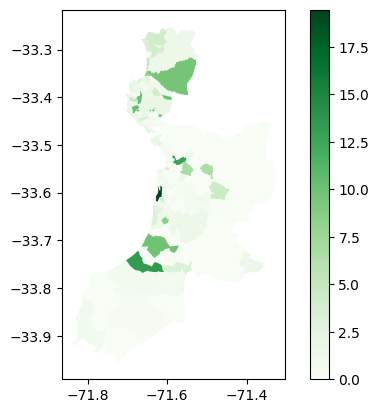

In [32]:
gdf.plot(column='ptje_migrantes',
        cmap='Greens',
        legend = 'True')

# 3. EDA
## 3.1 Estadísticos Descriptivos

In [33]:
gdf[['ptje_migrantes', 'ptje_esc_mayor_16']].describe().round(2)

,ptje_migrantes,ptje_esc_mayor_16
count,162.00,162.00
mean,1.58,11.43
std,2.75,9.59
min,0.00,0.00
25%,0.00,5.18
50%,0.64,8.82
75%,1.78,15.10
max,19.45,60.16


Text(0.5, 1.0, '%Migrantes')

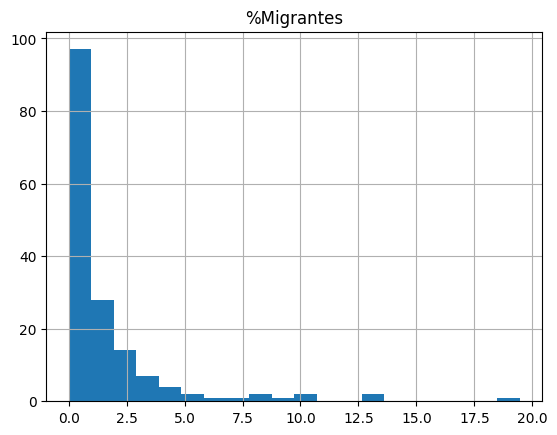

In [38]:
gdf['ptje_migrantes'].hist(bins=20)
plt.title('%Migrantes')